### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [6]:
titanic = sns.load_dataset('titanic')
print(titanic.columns)
print(titanic.info())
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [7]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic.isnull().sum(axis=0)        # isnull() : null이면 True, null이 아니면 False, axis=0: default

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# pandas 3.0부터 변경됨.
titanic.fillna({'age' : titanic['age'].mean()}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [10]:
titanic['age'].isnull().sum() 

np.int64(0)

In [11]:
titanic['embarked'].isnull().sum() 

np.int64(2)

In [12]:
titanic['embarked'].value_counts()      # embarked : 탑승항구 코드

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
titanic.fillna({'embarked':'n'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [14]:
titanic['embarked'].isnull().sum() 

np.int64(0)

In [15]:
titanic['embarked'].value_counts() 

embarked
S    644
C    168
Q     77
n      2
Name: count, dtype: int64

In [29]:
# dtype이 category이면 categories에 값을 먼저 등록해야 한다.
titanic['deck'] = titanic['deck'].cat.add_categories('N')
titanic.fillna({'deck':'N'}, inplace=True)

titanic['deck'].isnull().sum() 

np.int64(0)

In [17]:
titanic['deck'].value_counts() 

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

In [18]:
# titanic['deck'] = titanic['deck'].cat.add_categories('N')
titanic.fillna({'embark_town':'N'}, inplace=True)

titanic['embark_town'].isnull().sum() 

np.int64(0)

In [19]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [20]:
# 남, 여 탑승수
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [21]:
print(dir(titanic))

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod_

In [22]:
# 생존율 0(사망) : 549, 1(생존) : 342

titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [23]:
titanic.groupby(['sex'])

In [24]:
# 성별 생존여부
titanic.groupby(['sex'])['survived'].value_counts()

# titanic.groupby(['sex', 'survived'])['survived'].count()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

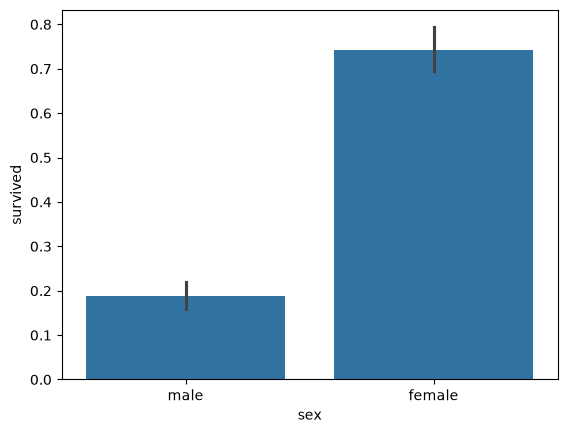

In [25]:
sns.barplot(data=titanic, x='sex', y='survived')

객실 등급별 성별에 따른 생존 확률</br>
- 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.
- 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.
- 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다. 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

<Axes: xlabel='pclass', ylabel='survived'>

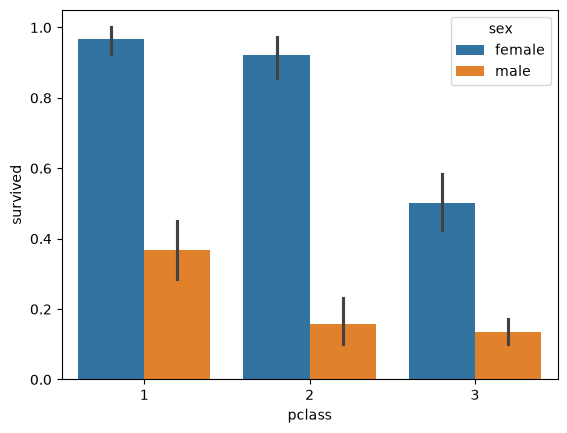

In [26]:
# 선실등급별 남여 생존여부
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

In [27]:
import platform
import sklearn

if platform.system() == 'Windows':
    sklearn.set_config(display='text')



In [30]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [32]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

### LabelEncoder()로 인코딩

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()

# 변환할 컬럼 목록(str, category)
label_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

for col in label_cols:
    titanic_df1[col] = le.fit_transform(titanic_df1[col])




In [34]:
titanic_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10), str(1)
memory usage: 92.4 KB


In [35]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,2,2,1,7,3
1,0,0,0,2,2,0
2,0,2,2,2,7,3
3,0,2,0,2,2,3
4,1,2,2,1,7,3


In [36]:
print(titanic['sex'].head())
print(titanic_df1['sex'].head())

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str
0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


In [37]:
titanic_df1['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [38]:
titanic_df1['deck'].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

### OneHotEncoder(sparse_output=False, handle_unknown='ignore')

OneHotEncoder(sparse_output=False, handle_unknown='ignore')

| 파라미터                      | 설명                                                                            |
| ------------------------- | ----------------------------------------------------------------------------- |
| `sparse_output=False`     | 반환값을 **희소 행렬(sparse matrix)** 대신 **NumPy 배열**로 반환. <br> → DataFrame으로 변환하기 쉬움 |
| `handle_unknown='ignore'` | 학습 시 보지 못한 **새로운 범주가 등장해도 에러 없이 무시**. <br> → 안정적인 예측 및 인코딩 수행                 |


In [46]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

titanic_df2 = titanic.copy()

# 변환할 컬럼 목록
ohe_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

ohe_result = pd.DataFrame(index = titanic_df2.index)
print('ohe_result:', ohe_result.head())
print('ohe_result_len:', len(ohe_result))

for col in ohe_cols:
    encoded = ohe.fit_transform(titanic_df2[[col]])
    # print(encoded)

    col_names = ohe.get_feature_names_out([col])
    # print(col_names)    # ['sex_female' 'sex_male']

    encoded_df = pd.DataFrame(encoded, columns=col_names, index = titanic_df2.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1) 
    # print(ohe_result.head())

    # break




ohe_result: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
ohe_result_len: 891


In [48]:
print(len(ohe_result.columns))
ohe_result.head()


24


,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_n,class_First,class_Second,class_Third,who_child,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
# survived와 alive 컬럼 2개가 생존 여부를 의미한다. 그래서 alive 컬럼을 삭제한다.
titanic_df2.drop(columns=['alive'], inplace=True)

In [54]:

# titanic_df2 = pd.concat([titanic_df2.drop(columns=ohe_cols)])
titanic_df2

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.000000,1,0,7.2500,True,False
1,1,1,38.000000,1,0,71.2833,False,False
2,1,3,26.000000,0,0,7.9250,False,True
3,1,1,35.000000,1,0,53.1000,False,False
4,0,3,35.000000,0,0,8.0500,True,True
...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,True
887,1,1,19.000000,0,0,30.0000,False,True
888,0,3,29.699118,1,2,23.4500,False,False
889,1,1,26.000000,0,0,30.0000,True,True


In [56]:
titanic_df2.drop(columns=ohe_cols, inplace=True)

KeyError: "['sex', 'embarked', 'class', 'who', 'deck', 'embark_town'] not found in axis"

In [57]:
titanic_df2 = pd.concat([titanic_df2, ohe_result], axis=1)

In [61]:
print(titanic_df2.columns)
titanic_df2.head(1)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q',
       'embarked_S', 'embarked_n', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='str')


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.25,True,False,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `alive`       | str   | LabelEncoder  | yes/no → 이진             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |

In [62]:
titanic_df3 = titanic.copy()

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alone']
le = LabelEncoder()

for col in label_cols:
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과를 저장할 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols:
    #encoded 타입은 ndarray
    encoded = ohe.fit_transform(titanic_df3[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df3.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

# 기존 원본 컬럼 삭제 후 병합
titanic_df3 = pd.concat([titanic_df3.drop(columns=ohe_cols), ohe_result], axis=1)
print(titanic_df3.info())






<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 891 non-null    int64  
 1   pclass                   891 non-null    int64  
 2   age                      891 non-null    float64
 3   sibsp                    891 non-null    int64  
 4   parch                    891 non-null    int64  
 5   fare                     891 non-null    float64
 6   class                    891 non-null    int64  
 7   adult_male               891 non-null    int64  
 8   alive                    891 non-null    str    
 9   alone                    891 non-null    int64  
 10  sex_female               891 non-null    float64
 11  sex_male                 891 non-null    float64
 12  embarked_C               891 non-null    float64
 13  embarked_Q               891 non-null    float64
 14  embarked_S               891 non-null

In [63]:
titanic_df3.drop(columns=['alive'], inplace=True)

In [64]:
titanic_df3.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class',
       'adult_male', 'alone', 'sex_female', 'sex_male', 'embarked_C',
       'embarked_Q', 'embarked_S', 'embarked_n', 'who_child', 'who_man',
       'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F',
       'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N',
       'embark_town_Queenstown', 'embark_town_Southampton'],
      dtype='str')

데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.

make_column_transformer를 이용한 인코딩
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

### make_column_transformer

In [93]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()

In [94]:
titanic_df4.drop(columns=['alive'], inplace=True)

In [73]:
titanic_df4.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='str')

In [95]:
# 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class', 'adult_male', 'alone']

# make_column_transformer
# remainder = 'passthrough' : 나머지 컬럼은 그대로 유지(예: age, fare 등)
column_transformer = make_column_transformer((OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
                                             (OrdinalEncoder(), ordinal_cols),
                                             remainder='passthrough')

# 변환 적용
encoded = column_transformer.fit_transform(titanic_df4)




In [96]:
# encoded
# titanic_df4

# 컬럼이름 추출
print(dir(column_transformer))
print(column_transformer.named_transformers_)

# rint(dir(column_transformer.named_transformers_['onehotencoder']))
onehot_feature_names = column_transformer.named_transformers_['onehotencoder'].get_feature_names_out(onehot_cols)
print(f'onehot_feature_name: {onehot_feature_names}')

ordinal_feature_names = ordinal_cols
print(f'ordinal_feature_names : {ordinal_feature_names}')

other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols]
print(f'other_feature_name : {other_feature_name}')

print(type(onehot_feature_names))   # <class 'numpy.ndarray'>
print(type(ordinal_feature_names))  # <class 'list'>
print(type(other_feature_name))     # <class 'list'>

final_feature_names = other_feature_name + list(onehot_feature_names) + ordinal_feature_names
print(f'final_feature_names : {final_feature_names}')

# DataFrame으로 변환
titanic_df4 = pd.DataFrame(encoded, columns=final_feature_names, index=titanic_df4.index)
print(titanic_df4.head())




['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_add_prefix_for_feature_names_out', '_call_func_on_transformers', '_check_estimators_are_instances', '_columns', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_class_level_metadata_request_values', '_get_doc_link', '_get_empty_routing', '_get_feature_name_out_for_transformer', '_get_fitted_attr_html', '_get_metadata_request', '_get_param_names', '_get_params', '_get_params_html', '_get_remainder_cols', '_get_remainder_cols_dtype', '_hstack', '_html_repr', '_iter', '_log_me

In [98]:
feature_names = column_transformer.get_feature_names_out()
# print(feature_names)

encoded_df_default = pd.DataFrame(encoded, columns=feature_names)
print(encoded_df_default)




     onehotencoder__sex_female  onehotencoder__sex_male  \
0                          0.0                      1.0   
1                          1.0                      0.0   
2                          1.0                      0.0   
3                          1.0                      0.0   
4                          0.0                      1.0   
..                         ...                      ...   
886                        0.0                      1.0   
887                        1.0                      0.0   
888                        1.0                      0.0   
889                        0.0                      1.0   
890                        0.0                      1.0   

     onehotencoder__embarked_C  onehotencoder__embarked_Q  \
0                          0.0                        0.0   
1                          1.0                        0.0   
2                          0.0                        0.0   
3                          0.0                 

In [99]:
titanic_df5 = titanic.copy()
column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder='passthrough',
    verbose_feature_names_out=False  # 접두사 제거 옵션
)

encoded = column_transformer_ignore.fit_transform(titanic_df5)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(f'encoded_df :{encoded_df.columns}')
print(encoded_df)

encoded_df :Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S',
       'embarked_n', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare', 'alive'],
      dtype='str')
    sex_female sex_male embarked_C embarked_Q embarked_S embarked_n who_child  \
0          0.0      1.0        0.0        0.0        1.0        0.0       0.0   
1          1.0      0.0        1.0        0.0        0.0        0.0       0.0   
2          1.0      0.0        0.0        0.0        1.0        0.0       0.0   
3          1.0      0.0        0.0        0.0        1.0        0.0       0.0   
4          0.0      1.0        0.0        0.0        1.0        0.0       0.0   
..         ...      ...        ...        ...     

ColumnTransformer는 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [108]:
from sklearn.compose import ColumnTransformer

titanic_df5 = titanic.copy()
titanic_df5.drop(columns=['alive'], inplace=True)

In [109]:
titanic_df5.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,N,Southampton,False


In [110]:
target = titanic_df5['survived']

In [111]:

titanic_df5 = titanic_df5.iloc[:, 1:]   # titanic_df5['sex'], titanic_df5[['sex', 'embarked', 'who']]
                # titanic_df5[1:] : 행 의미        

# 2. 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class',  'adult_male', 'alone']

# 3. ColumnTransformer 정의
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

# 4. 변환 실행
encoded_array = ct.fit_transform(titanic_df5)

# 5. 변환된 컬럼명 추출 및 DataFrame 생성
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)

# print(encoded_df.head())



In [112]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S',
       'embarked_n', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [ ]:
# titanic_df5 = pd.concat([target, encoded_df], axis=1)
# titanic_df5.head(1)

,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_n,who_child,who_man,who_woman,...,embark_town_Southampton,class,adult_male,alone,survived,pclass,age,sibsp,parch,fare
0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,2.0,1.0,0.0,0.0,3.0,22.0,1.0,0.0,7.25


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(encoded_df, target, test_size=0.25, stratify=target, shuffle=True)
print(f'X_train : ', X_train.shape)
print(f'X_test : ', X_test.shape)
print(f'y_train : ', y_train.shape)
print(f'y_test : ', y_test.shape)


print(f'train : {y_train.value_counts()}')
print(f'test : {y_test.value_counts()}')



X_train :  (668, 29)
X_test :  (223, 29)
y_train :  (668,)
y_test :  (223,)
train : survived
0    412
1    256
Name: count, dtype: int64
test : survived
0    137
1     86
Name: count, dtype: int64


In [123]:
# LogisticRegression 알고리즘
model = LogisticRegression(max_iter=1000)

# 훈련
model.fit(X_train, y_train)

# 테스트
y_pred = model.predict(X_test)



In [124]:
# 혼동 행렬
confusion_matrix(y_test, y_pred)

array([[116,  21],
       [ 22,  64]])

In [126]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       137
           1       0.75      0.74      0.75        86

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [120]:

# 평가지표
print('평가지표')
print(f'Accuracy : {accuracy_score(y_test, y_pred)}')
print(f'Precision : {precision_score(y_test, y_pred)}')
print(f'Recall : {recall_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')
# print(f'ROC AUC : {roc_auc_score(y_test, y_pred)}')

평가지표
Accuracy : 0.7982062780269058
Precision : 0.7126436781609196
Recall : 0.7560975609756098
F1 Score : 0.7337278106508875
